# Sin Preprocesamiento


En el presente notebook se generan y se evalúan los siguientes modelos.

* Regresión lineal (regularizada según elastic net)
* Árbol de regresión
* KNN para regresión
* Regresión no paramétrica

Al no utilizar ningún tipo de preprocesamiento, nos permite tener valores de referencia sobre los score de los distintos modelos. De este modo, podremos comparar los presentes resultados con los arrajados al modificar previamente el set de datos, y concluir si el preprocesamiento fue bueno o no. 

In [1]:
library(pracma)
library(glmnet)
library("partykit")
source("Utils.R")

Loading required package: Matrix
Loading required package: foreach
Loaded glmnet 2.0-16



### Division de los datos

In [2]:
setSeed()

vasijas_X <- obtener_X()
vasijas_Y <- obtener_Y()

df <- vasijas_X
df$Y <- vasijas_Y


hold_out_ind <- obtener_holdout_ind(vasijas_X)

HOLDOUT_X <- vasijas_X[hold_out_ind, ]
HOLDOUT_Y <- vasijas_Y[hold_out_ind]
HOLDOUT_DF <- df[hold_out_ind, ]

TRAIN_Y <- vasijas_Y[-hold_out_ind]
TRAIN_X <- vasijas_X[-hold_out_ind, ]
TRAIN_DF <- df[-hold_out_ind, ]

# Modelo 1: regresión lineal regularizada


### Sin tuneo de parametros

In [63]:
model <- glmnet(as.matrix(TRAIN_X), TRAIN_Y)

In [54]:
Y_pred = predict(model, as.matrix(TRAIN_X))
error_min <- sum((TRAIN_Y - Y_pred[, 1])^2) / nrow(TRAIN_X)
best_model <- 1
for (i in 2:ncol(Y_pred)) {
    curr_error <- sum((TRAIN_Y - Y_pred[, i])^2) / nrow(TRAIN_X)
    if (curr_error < error_min) {
        error_min <- curr_error 
        best_model <- i
    }
}
print(paste("El error cuadratico medio de train es: ", error_min, " usando el modelo numero: ", best_model))

[1] "El error cuadratico medio de train es:  0.694377895643682  usando el modelo numero:  100"


In [56]:
Y_pred = predict(model, as.matrix(HOLDOUT_X))
error <- sum((HOLDOUT_Y - Y_pred[, best_model])^2) / nrow(HOLDOUT_X)
print(paste("El error cuadratico medio de test es: ", error))

[1] "El error cuadratico medio de test es:  0.963803003107569"


Es claro que hay un overfitting bastante grande

### Busqueda de los parametros de la prediccion

In [75]:
setSeed()
n = nrow(TRAIN_X)
k = 5
resultados <- data.frame(
  Alpha   =double(),
  Lambda  =double(),
  Error   =double()
)

indices = obtener_indices_kfold(n, k)
X <- TRAIN_X

alphas <- seq(0, 1, 0.05)
lambdas <- logspace(-10, 3, 50)

for (alpha in alphas) {
    for (lambda in lambdas) {
        err = 0
        for (i in indices) {
            X_train_scaled = scale(X[-i,])
            Y_train = TRAIN_Y[-i]

            X_test_scaled = scale(X[i,], center=attr(X_train_scaled, "scaled:center"),
                          scale=attr(X_train_scaled, "scaled:scale"))

            Y_test = TRAIN_Y[i]

            model <- glmnet(X_train_scaled, Y_train, lambda=lambda, alpha=alpha)
            Y_pred = predict(model, X_test_scaled)
            err = err + sum((Y_test - Y_pred)^2)
        }
        resultados = rbind(resultados, list(alpha, lambda, err/n))
    }
    message(progreso(alpha, alphas))
}

colnames(resultados)  <- c("alpha", "lambda", "Error")

El progreso es del 4.8 %
El progreso es del 9.5 %
El progreso es del 14.3 %
El progreso es del 19 %
El progreso es del 23.8 %
El progreso es del 28.6 %
El progreso es del 33.3 %
El progreso es del 38.1 %
El progreso es del 42.9 %
El progreso es del 47.6 %
El progreso es del 52.4 %
El progreso es del 57.1 %
El progreso es del 61.9 %
El progreso es del 66.7 %
El progreso es del 71.4 %
El progreso es del 76.2 %
El progreso es del 81 %
El progreso es del 85.7 %
El progreso es del 90.5 %
El progreso es del 95.2 %
El progreso es del 100 %


Los mejores parámetros obtenidos fueron entonces:

In [76]:
mejores_parametros <- resultados[which.min(resultados$Error),]
mejores_parametros

,alpha,lambda,Error
184,0.15,0.05689866,0.9506797


### Calculo del error

In [81]:
X_scaled <- scale(TRAIN_X)
X_holdout_scaled <- scale(HOLDOUT_X, center=attr(X_scaled, "scaled:center"),
                          scale=attr(X_scaled, "scaled:scale"))
model <- glmnet(X_scaled, TRAIN_Y, alpha=mejores_parametros$alpha, lambda=mejores_parametros$lambda)

In [82]:
Y_pred = predict(model, X_scaled)
error <- sum((TRAIN_Y - Y_pred)^2) / nrow(TRAIN_X)
print(paste("El error cuadratico medio de train es: ", error))

Y_pred = predict(model, X_holdout_scaled)
error <- sum((HOLDOUT_Y - Y_pred)^2) / nrow(HOLDOUT_X)
print(paste("El error cuadratico medio de test es: ", error))

[1] "El error cuadratico medio de train es:  0.252576323561401"
[1] "El error cuadratico medio de test es:  1.08320235995546"


In [107]:
n = nrow(TRAIN_X)
indices = obtener_indices_kfold(n, n)
X <- TRAIN_X
err = 0
for(i in indices){

    X_train_scaled = scale(X[-i,])
    Y_train = TRAIN_Y[-i]

    X_test_scaled = scale(X[i,], center=attr(X_train_scaled, "scaled:center"),
                  scale=attr(X_train_scaled, "scaled:scale"))

    Y_test = TRAIN_Y[i]

    model <- glmnet(X_train_scaled, Y_train, lambda=mejores_parametros$lambda, alpha=mejores_parametros$alpha)
    Y_pred = predict(model, X_test_scaled)
    err = err + sum((Y_test - Y_pred)^2)
}
err = err/n
print(paste("El error cuadratico medio con LOOCV de train es: ", err))

[1] 0.8649772


# llama mucho la atencion el error de test tanto mas alto luego de hacer cross validation

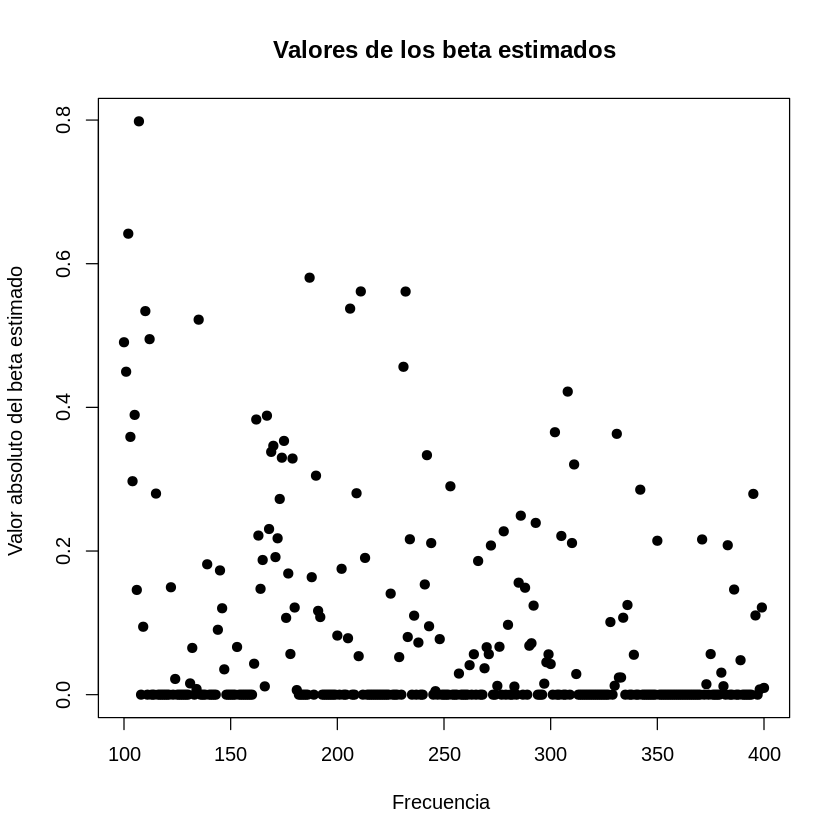

In [104]:
plot(x = seq(100, 400,1), y = abs(model$beta[,1]), main="Valores de los beta estimados",
     xlab="Frecuencia ", ylab="Valor absoluto del beta estimado ", pch=19)

### Analisis del grafico

En el presente grafico se puede observar la importancia que le da el modelo a las distintas variables $X_i$. Dado que el valor de $\alpha = 0.15 $ es cercano a cero, es esperable que muchas variables no sean tenidas en cuenta por el modelo (hay penalizacion por la distancia $L1$). Ademas, aunque no es muy notorio, pareciera que las variables a las que se les da mayor importancia son a las de frecuencia baja, mientras que a las de frecuencia alta, se les da poco protagonismo en el modelo

# Modelo 2: árbol de regresión

### Sin tuneo de parametros

In [126]:
model <- ctree(Y ~ ., data = TRAIN_DF)

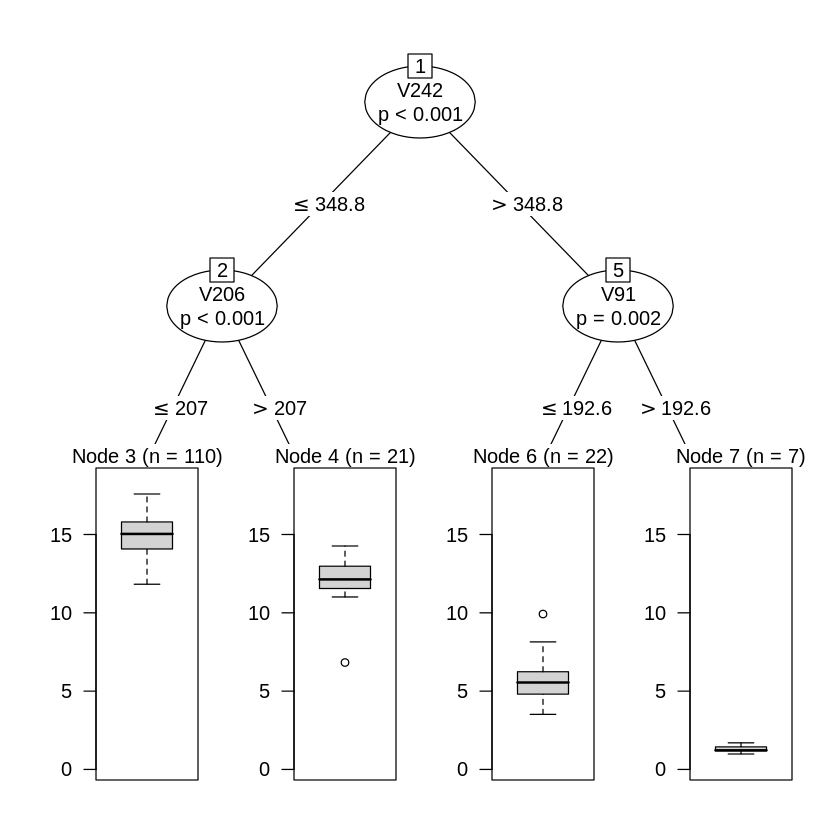

In [132]:
plot(model)

In [139]:
Y_pred = predict(model, TRAIN_X)
error <- sum((TRAIN_Y - Y_pred)^2) / nrow(TRAIN_X)
print(paste("El error cuadratico medio de train es: ", error))

[1] "El error cuadratico medio de train es:  1.54697910764069"


In [140]:
Y_pred = predict(model, HOLDOUT_X)
error <- sum((HOLDOUT_Y - Y_pred)^2) / nrow(HOLDOUT_X)
print(paste("El error cuadratico medio de test es: ", error))

[1] "El error cuadratico medio de test es:  0.983107098052772"


### Busqueda de los parametros de la prediccion

In [116]:
setSeed()

n = nrow(TRAIN_X)
k = 10

resultados <- data.frame(
  Minsplit =double(),
  Maxdepth =double(),
  Alpha    =double(),
  Error    =double()
)

indices = obtener_indices_kfold(n, k)

X <- TRAIN_X

minsplits <- c(2, 5, 10, 20, 30, 50)

for (minsplit in minsplits) {
    for (maxdepth in c(1, 2, 3, 4, 5, Inf)) {
        for (alpha in c(0.005, 0.01, 0.025, 0.05, 0.75, 0.1, 0.15)) {
            parametros = ctree_control(minsplit=minsplit, maxdepth=maxdepth, alpha=alpha)
            err = 0
            for(i in indices) {
                DF_train = X[-i,]
                DF_train$Y = TRAIN_Y[-i]

                DF_test = X[i,]
                DF_test$Y = TRAIN_Y[i]

                model <- ctree(Y ~ ., data = DF_train, control=parametros)
                Y_pred = predict(model, DF_test)
                err = err + sum((DF_test$Y - Y_pred)^2)
            }
            resultados = rbind(resultados, list(minsplit, maxdepth, alpha, err/n))
        }
    }
    message(progreso(minsplit, minsplits))
}

colnames(resultados)  <- c("Minsplit", "Maxdepth", "Alpha", "Error")

El progreso es del 16.7 %
El progreso es del 33.3 %
El progreso es del 50 %
El progreso es del 66.7 %
El progreso es del 83.3 %
El progreso es del 100 %


In [117]:
mejores_parametros <- resultados[which.min(resultados$Error),]
mejores_parametros

,Minsplit,Maxdepth,Alpha,Error
40,2,Inf,0.75,2.001328


### Calculo del error

In [118]:
parametros <- ctree_control(minsplit=mejores_parametros$Minsplit, maxdepth=mejores_parametros$Maxdepth, alpha=mejores_parametros$Alpha)

modelo2 <- ctree(Y ~ ., data = TRAIN_DF, control=parametros)

In [151]:
Y_pred = predict(model, TRAIN_X)
error <- sum((TRAIN_Y - Y_pred)^2) / nrow(TRAIN_X)
print(paste("El error cuadratico medio de train es: ", error))

Y_pred = predict(model, HOLDOUT_X)
error <- sum((HOLDOUT_Y - Y_pred)^2) / nrow(HOLDOUT_X)
print(paste("El error cuadratico medio de test es: ", error))

n = nrow(TRAIN_X)
indices = obtener_indices_kfold(n, n)
X <- TRAIN_X
err = 0
for(i in indices){
    X_train <- X[-i,]
    Y_train <- TRAIN_Y[-i]
    train_df <- X_train
    train_df$Y <- Y_train
    X_test <- X[i,]
    Y_test = TRAIN_Y[i]

    model <- ctree(Y ~ ., data = train_df, control=parametros)
    Y_pred = predict(model, X_test)
    err = err + sum((Y_test - Y_pred)^2)
}
err = err/n
print(paste("El error cuadratico medio con LOOCV de train es: ", err))

[1] "El error cuadratico medio de train es:  1.54697910764069"
[1] "El error cuadratico medio de test es:  0.983107098052772"
[1] "El error cuadratico medio con LOOCV de train es:  2.05346048565848"


# Modelo 3: KNN para regresión

In [122]:
library(reticulate)

In [147]:
np <- import("numpy", convert = FALSE)
pd <- import("pandas", convert = FALSE)

In [150]:
py_install("sklearn")

ERROR: Error: one or more Python packages failed to install [error code 1]


In [149]:
knnr <- import("sklearn.neighbors", convert = FALSE)$KNeighborsRegressor

ERROR: Error in py_module_import(module, convert = convert): ModuleNotFoundError: No module named 'sklearn'

Detailed traceback:
  File "/home/matecapo67/anaconda3/lib/R/library/reticulate/python/rpytools/loader.py", line 44, in _import_hook
    level=level



### Sin tuneo de parametros

In [ ]:
model <- knnr()$fit(TRAIN_X, TRAIN_Y)

In [ ]:
Y_pred = as.double(model$predict(TRAIN_X))
error <- sum((TRAIN_Y - Y_pred)^2) / nrow(TRAIN_X)
print(paste("El error cuadratico medio de train es: ", error))

Y_pred = predict(model, HOLDOUT_X)
error <- sum((HOLDOUT_Y - Y_pred)^2) / nrow(HOLDOUT_X)
print(paste("El error cuadratico medio de test es: ", error))

### Busqueda de los parametros de la prediccion

In [ ]:
setSeed()

n = nrow(TRAIN_X)
k = 10

resultados <- data.frame(
    K        =integer(),
    Weights  =integer(),
    p        =integer(),
    Error    =double()
)

indices = obtener_indices_kfold(n, k)

    X <- TRAIN_X

for(K in 1:10){
    for(w in c(1, 2)){
        wei = ifelse(w==1, "uniform", "distance")
        for(p in c(1, 2)){
            err = 0
            for(i in indices){
                X_train_scaled = scale(X[-i,])
                Y_train = TRAIN_Y[-i]

                X_test_scaled = scale(X[i,], center=attr(X_train_scaled, "scaled:center"),
                              scale=attr(X_train_scaled, "scaled:scale"))
                Y_test = TRAIN_Y[i]

                model <- knnr(n_neighbors=K, p=p, weights=wei)$fit(X_train_scaled, Y_train)

                Y_pred = as.double(model$predict(X_test_scaled))
                err = err + sum((Y_test - Y_pred)^2)
            }
            resultados = rbind(resultados, list(K, w, p, err/n))
        }
    }
    message(progreso(K, 1:10))
}
colnames(resultados)  <- c("K", "Weights", "Distance", "Error")

In [ ]:
mejores_parametros <- resultados[which.min(resultados$Error),]
mejores_parametros

### Calculo del error

In [ ]:
X_scaled <- scale(TRAIN_X)
X_holdout_scaled <- scale(HOLDOUT_X, center=attr(X_scaled, "scaled:center"),
                          scale=attr(X_scaled, "scaled:scale"))

wei <- = ifelse(mejores_parametros$w==1, "uniform", "distance")
modelo3 <- knnr(n_neighbors=mejores_parametros$K, p=mejores_parametros$p, weights=wei)$fit(X_scaled, TRAIN_Y)

In [ ]:
Y_pred = predict(model, X_scaled)
error <- sum((TRAIN_Y - Y_pred)^2) / nrow(TRAIN_X)
print(paste("El error cuadratico medio de train es: ", error))


Y_pred = predict(model, X_holdout_scaled)
error <- sum((HOLDOUT_Y - Y_pred)^2) / nrow(HOLDOUT_X)
print(paste("El error cuadratico medio de test es: ", error))


n = nrow(TRAIN_X)
indices = obtener_indices_kfold(n, n)
X <- TRAIN_X
err = 0
for(i in indices){
    X_train_scaled = scale(X[-i,])
    Y_train = TRAIN_Y[-i]

    X_test_scaled = scale(X[i,], center=attr(X_train_scaled, "scaled:center"),
                  scale=attr(X_train_scaled, "scaled:scale"))
    Y_test = TRAIN_Y[i]

    model <- knnr(n_neighbors=mejores_parametros$K, p=mejores_parametros$p, weights=wei)$fit(X_train_scaled, Y_train)
    Y_pred = predict(model, X_test_scaled)
    err = err + sum((Y_test - Y_pred)^2)
}
err = err/n
print(paste("El error cuadratico medio con LOOCV de train es: ", err))

# Modelo 4: regresión no paramétrica

In [152]:
# CITAMOS: https://bookdown.org/egarpor/PM-UC3M/npreg-kre.html

# A naive implementation of the Nadaraya-Watson estimator
mNW <- function(x, X, Y, h, K = dnorm) {

  # Arguments
  # x: evaluation points
  # X: vector (size n) with the predictors
  # Y: vector (size n) with the response variable
  # h: bandwidth
  # K: kernel

  # Matrix of size n x length(x)
  Kx <- sapply(X, function(Xi) K((x - Xi) / h) / h)

  # Weights
  W <- Kx / rowSums(Kx) # Column recycling!

  # Means at x ("drop" to drop the matrix attributes)
  drop(W %*% Y)
}

In [198]:
corr_matrix <- cor(TRAIN_DF, method = "pearson")
corr_pesos <- corr_matrix[, 302][1:301]
corr_pesos <- abs(corr_pesos)

In [201]:
sum(corr_pesos) 

[1] 135.7105

In [207]:
setSeed()
n = nrow(TRAIN_X)
k = 5
resultados <- data.frame(
  h       =double(),
  Error   =double()
)

indices = obtener_indices_kfold(n, k)
X <- TRAIN_X
pesos <- corr_pesos
for (h in seq(0.01, 1, 0.1)) {
    err = 0
    for (i in indices) {
        #escalamos por la ventana h.
        X_train_scaled = scale(X[-i,])
        Y_train = TRAIN_Y[-i]

        X_test_scaled = scale(X[i,], center=attr(X_train_scaled, "scaled:center"),
                      scale=attr(X_train_scaled, "scaled:scale"))
        Y_test = TRAIN_Y[i]
        Y_pred = as.double(pesos[1]) * mNW(x = X_test_scaled[,1], X = X_train_scaled[,1], Y = Y_train, h = h)   
        for (i in seq(2, 301)) {
            Y_pred = Y_pred + as.double(pesos[i]) * mNW(x = X_test_scaled[,i], X = X_train_scaled[,i], Y = Y_train, h = h)   
        }
        Y_pred = Y_pred / sum(pesos)
        err = err + sum((Y_test - Y_pred)^2)
    }
    resultados = rbind(resultados, list(h, err/n))
    message(progreso(h, seq(0.01, 1, 0.01)))

}


colnames(resultados)  <- c("h", "Error")

El progreso es del 1 %
El progreso es del 11 %
El progreso es del 21 %
???
El progreso es del 41 %
El progreso es del 51 %
???
El progreso es del 71 %
El progreso es del 81 %
El progreso es del 91 %


In [208]:
mejores_parametros <- resultados[which.min(resultados$Error),]
mejores_parametros

,h,Error
2,0.11,5.485534
